# Analista de Experiencia del Cliente: 29/06/2026

## Pregunta de negocio

**¿Cuál es la puntuación media dada por los usuarios a los alojamientos turísticos y qué porcentaje de alojamientos tienen una evaluación general superior a 80 en cada ciudad?**

Este notebook corresponde al perfil de **Analista de Experiencia del Cliente** del Sprint 1 y utiliza directamente el dataset final después de Data Cleaning, Data Transformation y Data Reduction.


## Variables principales

- `apartment_id`: identificador único del alojamiento.
- `city`: ciudad del alojamiento.
- `review_scores_rating`: valoración general en escala de 0 a 100.
- `rating_above_80`: indica si la valoración general es superior a 80.

Para el KPI 4 se utilizan también las siguientes puntuaciones:

- `review_scores_accuracy`: precisión,
- `review_scores_cleanliness`: limpieza.
- `review_scores_checkin`: check-in.
- `review_scores_communication`: comunicación.
- `review_scores_location`: ubicación.

## Objetivos del análisis

- Calcular el **KPI 3: índice de satisfacción general**.
- Calcular la puntuación media por ciudad.
- Calcular el porcentaje de alojamientos con puntuación superior a 80 por ciudad.
- Mostrar el número de alojamientos evaluados y la cobertura de valoraciones.
- Calcular el **KPI 4: ítem con mayor satisfacción promedio**.
- Generar conclusiones y recomendaciones para el área de experiencia del cliente.

Los alojamientos sin puntuación no se consideran como puntuaciones bajas. Se excluyen únicamente del denominador de las métricas que requieren una valoración válida.


## 1. Importación de librerías

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch


## Sistema visual StaySpain

Esta configuración utiliza la misma identidad visual definida por el equipo
para los análisis de Marketing, Operaciones y Experiencia del Cliente.


In [2]:
# ============================================================
# COLORES CORPORATIVOS StaySpain
# ============================================================

NAVY = "#173453"
ACERO = "#2E6B96"
TEAL = "#2F8F8F"
AQUA = "#5FBDB0"
AMARILLO = "#F6C445"
AMBAR = "#E08A3C"
CIELO = "#6FA8C7"
TERRACOTA = "#C25B4E"

TINTA = "#0b0b0b"
TINTA_SUAVE = "#52514e"
EJES = "#898781"
REJILLA = "#e1e0d9"
BLANCO = "#FFFFFF"
FONDO_SUAVE = "#F7F7F5"

COLOR_CIUDAD = {
    "barcelona": NAVY,
    "girona": ACERO,
    "madrid": TEAL,
    "malaga": AQUA,
    "mallorca": AMARILLO,
    "menorca": AMBAR,
    "sevilla": CIELO,
    "valencia": TERRACOTA,
}

COLOR_TIPO = {
    "Entire home/apt": NAVY,
    "Hotel room": TEAL,
    "Private room": ACERO,
    "Shared room": AMARILLO,
}

plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": TINTA,
        "axes.labelcolor": TINTA_SUAVE,
        "axes.edgecolor": EJES,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": REJILLA,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": TINTA_SUAVE,
        "ytick.color": TINTA_SUAVE,
        "axes.axisbelow": True,
        "figure.facecolor": BLANCO,
        "axes.facecolor": BLANCO,
    }
)

_ESTILOS_TABLA = [
    {
        "selector": "caption",
        "props": [
            ("font-size", "14px"),
            ("font-weight", "bold"),
            ("color", TINTA),
            ("text-align", "left"),
            ("padding", "6px 2px"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("background-color", "#f0efec"),
            ("color", TINTA),
            ("font-weight", "600"),
            ("text-align", "center"),
            ("padding", "6px 10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "right"),
            ("padding", "4px 10px"),
        ],
    },
]

MAPA_STAYSPAIN = LinearSegmentedColormap.from_list(
    "stay_spain",
    [FONDO_SUAVE, AQUA, TEAL, NAVY],
)


def color_ciudad(ciudad):
    """Devuelve el color corporativo de una ciudad."""
    return COLOR_CIUDAD.get(
        str(ciudad).lower(),
        ACERO,
    )


def mostrar_tabla(
    dataframe,
    titulo,
    formatos=None,
    gradiente=None,
    indice=False,
):
    """Muestra una tabla con el estilo visual StaySpain."""
    tabla = (
        dataframe.style
        .set_caption(titulo)
        .set_table_styles(_ESTILOS_TABLA)
        .set_properties(
            **{
                "border": f"1px solid {REJILLA}",
            }
        )
    )

    if formatos:
        tabla = tabla.format(formatos)

    if gradiente:
        tabla = tabla.background_gradient(
            subset=gradiente,
            cmap=MAPA_STAYSPAIN,
        )

    if not indice:
        tabla = tabla.hide(axis="index")

    display(tabla)


def etiquetas_barras(
    ax,
    sufijo="",
    decimales=2,
    desplazamiento=0.3,
):
    """Añade valores al final de barras horizontales."""
    for barra in ax.patches:
        valor = barra.get_width()
        ax.text(
            valor + desplazamiento,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.{decimales}f}{sufijo}",
            va="center",
            fontsize=9,
            color=TINTA_SUAVE,
        )


def grafico_barras_ciudad(
    datos,
    valor,
    titulo,
    etiqueta_x,
    benchmark=None,
    etiqueta_benchmark=None,
    sufijo="",
    limite_x=None,
    desplazamiento=0.3,
):
    """Crea un gráfico horizontal por ciudad."""
    ordenados = datos.sort_values(valor)
    colores = [
        color_ciudad(ciudad)
        for ciudad in ordenados["city"]
    ]

    ax = ordenados.plot(
        x="city",
        y=valor,
        kind="barh",
        color=colores,
        legend=False,
    )

    if benchmark is not None:
        ax.axvline(
            benchmark,
            color=AMARILLO,
            linestyle="--",
            linewidth=2,
            label=etiqueta_benchmark,
        )
        ax.legend(frameon=False)

    ax.set(
        title=titulo,
        xlabel=etiqueta_x,
        ylabel="Ciudad",
    )

    if limite_x:
        ax.set_xlim(*limite_x)

    etiquetas_barras(
        ax,
        sufijo=sufijo,
        desplazamiento=desplazamiento,
    )
    plt.tight_layout()
    plt.show()


def mostrar_tarjetas_kpi(tarjetas, titulo):
    """Muestra una fila de tarjetas KPI."""
    fig, axes = plt.subplots(
        1,
        len(tarjetas),
        figsize=(14, 3.5),
    )

    for ax, (nombre, valor, color) in zip(
        axes,
        tarjetas,
    ):
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")

        tarjeta = FancyBboxPatch(
            (0.04, 0.08),
            0.92,
            0.80,
            boxstyle=(
                "round,pad=0.025,"
                "rounding_size=0.05"
            ),
            facecolor=color,
            edgecolor=color,
        )
        ax.add_patch(tarjeta)

        ax.text(
            0.50,
            0.58,
            valor,
            ha="center",
            va="center",
            fontsize=21,
            fontweight="bold",
            color=BLANCO,
        )
        ax.text(
            0.50,
            0.30,
            nombre,
            ha="center",
            va="center",
            fontsize=10,
            color=BLANCO,
        )

    fig.suptitle(
        titulo,
        fontsize=16,
        fontweight="bold",
        color=TINTA,
    )
    plt.tight_layout()
    plt.show()


def grafico_relacion_ciudades(
    datos,
    x,
    y,
    tamano,
    benchmark_x,
    benchmark_y,
    titulo,
):
    """Representa la relación entre dos KPI por ciudad."""
    datos = datos.dropna(
        subset=[x, y, tamano]
    ).copy()

    tamanos = (
        datos[tamano] / datos[tamano].max()
        * 900
        + 100
    )

    colores = [
        color_ciudad(ciudad)
        for ciudad in datos["city"]
    ]

    fig, ax = plt.subplots()

    ax.scatter(
        datos[x],
        datos[y],
        s=tamanos,
        c=colores,
        alpha=0.75,
        edgecolors=BLANCO,
        linewidths=1,
    )
    ax.axvline(
        benchmark_x,
        color=AMARILLO,
        linestyle="--",
        linewidth=1.8,
    )
    ax.axhline(
        benchmark_y,
        color=AMARILLO,
        linestyle="--",
        linewidth=1.8,
    )

    for _, fila in datos.iterrows():
        ax.annotate(
            fila["city"].capitalize(),
            (fila[x], fila[y]),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9,
        )

    ax.set(
        title=titulo,
        xlabel="Puntuación media (0–100)",
        ylabel="Alojamientos con puntuación > 80 (%)",
    )
    plt.tight_layout()
    plt.show()


def mapa_calor(datos, etiquetas_x, titulo):
    """Muestra una matriz de valores como mapa de calor."""
    fig, ax = plt.subplots()

    imagen = ax.imshow(
        datos.values,
        aspect="auto",
        cmap=MAPA_STAYSPAIN,
    )

    ax.set_xticks(range(len(etiquetas_x)))
    ax.set_xticklabels(
        etiquetas_x,
        rotation=30,
        ha="right",
    )

    ax.set_yticks(range(len(datos.index)))
    ax.set_yticklabels(
        [
            ciudad.capitalize()
            for ciudad in datos.index
        ]
    )

    for fila in range(datos.shape[0]):
        for columna in range(datos.shape[1]):
            valor = datos.iloc[fila, columna]
            ax.text(
                columna,
                fila,
                f"{valor:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    BLANCO
                    if valor >= 9
                    else TINTA
                ),
            )

    barra = plt.colorbar(
        imagen,
        ax=ax,
    )
    barra.set_label(
        "Puntuación media (0–10)"
    )
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


## 2. Localización del dataset final

La ruta absoluta del ordenador no se guarda ni se muestra. El notebook busca automáticamente la carpeta `Equip_34` y carga el dataset final desde `Data/clean_dataset_29_06_2026.csv`.


In [3]:
def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}'."
    )


raiz_proyecto = encontrar_raiz_proyecto()

ruta_datos = (
    raiz_proyecto
    / "Data"
    / "clean_dataset_29_06_2026.csv"
)

print(
    "Dataset utilizado:",
    f"Data/{ruta_datos.name}",
)

Dataset utilizado: Data/clean_dataset_29_06_2026.csv


## 3. Carga del dataset final

In [4]:
df = pd.read_csv(ruta_datos)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Filas: 6733
Columnas: 18


,apartment_id,city,room_type,price_€,availability_30,availability_60,availability_90,availability_365,has_availability_numeric,occupancy_30,occupancy_rate_30,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,rating_above_80
0,13707226,barcelona,Private room,600.0,30,60,90,180,NaN,0,0.00,94.0,10.0,9.0,9.0,9.0,9.0,True
1,13011987,barcelona,Entire home/apt,650.0,0,0,0,20,NaN,30,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,14999488,barcelona,Private room,250.0,4,18,48,104,NaN,26,86.67,90.0,10.0,10.0,10.0,9.0,10.0,True
3,6547870,barcelona,Entire home/apt,750.0,30,45,47,238,NaN,0,0.00,86.0,9.0,8.0,9.0,9.0,9.0,True
4,15253506,barcelona,Entire home/apt,3150.0,11,36,65,338,NaN,19,63.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Validación de las variables necesarias

Esta sección no repite Cleaning ni Transformation. Solo comprueba que el dataset final contiene las columnas y escalas necesarias para el análisis.


In [5]:
columnas_principales = [
    "apartment_id",
    "city",
    "review_scores_rating",
    "rating_above_80",
]

columnas_satisfaccion = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
]

columnas_necesarias = (
    columnas_principales
    + columnas_satisfaccion
)

columnas_faltantes = [
    columna
    for columna in columnas_necesarias
    if columna not in df.columns
]

if columnas_faltantes:
    raise ValueError(
        "Faltan columnas necesarias para el análisis: "
        f"{columnas_faltantes}"
    )

print("Todas las columnas necesarias están disponibles.")

Todas las columnas necesarias están disponibles.


In [6]:
duplicados_id = df["apartment_id"].duplicated().sum()

print("Apartment ID duplicados:", duplicados_id)

if duplicados_id > 0:
    raise ValueError(
        "El dataset final contiene apartment_id duplicados."
    )

Apartment ID duplicados: 0


In [7]:
rating_valido = (
    df["review_scores_rating"].isna()
    | df["review_scores_rating"].between(0, 100)
)

if not rating_valido.all():
    raise ValueError(
        "review_scores_rating contiene valores fuera de 0–100."
    )

for columna in columnas_satisfaccion:
    valores_validos = (
        df[columna].isna()
        | df[columna].between(0, 10)
    )

    if not valores_validos.all():
        raise ValueError(
            f"{columna} contiene valores fuera de 0–10."
        )

print("Las escalas de puntuación son correctas.")

Las escalas de puntuación son correctas.


In [8]:
df["rating_above_80"] = (
    df["rating_above_80"]
    .astype("boolean")
)

coherencia_rating = (
    df["review_scores_rating"].isna()
    & df["rating_above_80"].isna()
) | (
    df["review_scores_rating"].notna()
    & (
        df["rating_above_80"]
        == (df["review_scores_rating"] > 80)
    )
)

if not coherencia_rating.all():
    raise ValueError(
        "rating_above_80 no es coherente con review_scores_rating."
    )

print("rating_above_80 es coherente con la puntuación general.")

rating_above_80 es coherente con la puntuación general.


## 5. Valores nulos y base analítica

In [9]:
resumen_nulos = (
    df[columnas_necesarias]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("Valores nulos")
    .reset_index(name="Valores nulos")
)

resumen_nulos.columns = [
    "Variable",
    "Valores nulos",
]

resumen_nulos["% nulos"] = (
    resumen_nulos["Valores nulos"]
    / len(df)
    * 100
).round(2)

mostrar_tabla(
    resumen_nulos,
    "Resumen de valores nulos",
    formatos={
        "Valores nulos": "{:,.0f}",
        "% nulos": "{:.2f}%",
    },
    gradiente=["% nulos"],
)


Variable,Valores nulos,% nulos
review_scores_location,"1,289",19.14%
review_scores_checkin,"1,288",19.13%
review_scores_accuracy,"1,283",19.06%
review_scores_communication,"1,279",19.00%
review_scores_cleanliness,"1,277",18.97%
review_scores_rating,"1,274",18.92%
rating_above_80,"1,274",18.92%
apartment_id,0,0.00%
city,0,0.00%


In [10]:
df_customer = df.dropna(
    subset=[
        "city",
        "review_scores_rating",
    ]
).copy()

if df_customer.empty:
    raise ValueError(
        "No hay alojamientos con ciudad y puntuación válidas."
    )

print(
    "Alojamientos totales:",
    df["apartment_id"].nunique(),
)

print(
    "Alojamientos con puntuación válida:",
    df_customer["apartment_id"].nunique(),
)

Alojamientos totales: 6733
Alojamientos con puntuación válida: 5459


## 6. KPI 3 — Índice de satisfacción general

In [11]:
indice_satisfaccion_general = round(
    df_customer["review_scores_rating"].mean(),
    2,
)

print(
    "Índice de satisfacción general:",
    indice_satisfaccion_general,
)

Índice de satisfacción general: 92.0


## 7. Puntuación media por ciudad

In [12]:
puntuacion_media_ciudad = (
    df_customer
    .groupby("city")["review_scores_rating"]
    .mean()
    .round(2)
    .reset_index(
        name="average_rating"
    )
    .sort_values(
        "average_rating",
        ascending=False,
    )
)

puntuacion_media_ciudad

,city,average_rating
6,sevilla,93.79
5,menorca,93.47
4,mallorca,93.44
2,madrid,92.75
7,valencia,92.28
3,malaga,92.13
1,girona,91.13
0,barcelona,90.68


## 8. Porcentaje de alojamientos con puntuación superior a 80

El porcentaje se calcula únicamente sobre los alojamientos que tienen una puntuación general válida en cada ciudad.


In [13]:
porcentaje_superior_80_ciudad = (
    df_customer
    .groupby("city")["rating_above_80"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(
        name="percentage_over_80"
    )
    .sort_values(
        "percentage_over_80",
        ascending=False,
    )
)

porcentaje_superior_80_ciudad

,city,percentage_over_80
6,sevilla,97.14
5,menorca,93.1
2,madrid,92.46
7,valencia,92.11
3,malaga,90.97
4,mallorca,90.68
0,barcelona,87.39
1,girona,84.22


## 9. Número de alojamientos evaluados y cobertura

In [14]:
alojamientos_evaluados_ciudad = (
    df_customer
    .groupby("city")["apartment_id"]
    .nunique()
    .reset_index(
        name="rated_accommodations"
    )
)

alojamientos_totales_ciudad = (
    df
    .groupby("city")["apartment_id"]
    .nunique()
    .reset_index(
        name="total_accommodations"
    )
)

cobertura_valoraciones_ciudad = (
    alojamientos_totales_ciudad
    .merge(
        alojamientos_evaluados_ciudad,
        on="city",
        how="left",
    )
)

cobertura_valoraciones_ciudad["rating_coverage_pct"] = (
    cobertura_valoraciones_ciudad["rated_accommodations"]
    / cobertura_valoraciones_ciudad["total_accommodations"]
    * 100
).round(2)

cobertura_valoraciones_ciudad

,city,total_accommodations,rated_accommodations,rating_coverage_pct
0,barcelona,2041,1697,83.15
1,girona,1085,754,69.49
2,madrid,1396,1194,85.53
3,malaga,339,310,91.45
4,mallorca,1096,794,72.45
5,menorca,138,116,84.06
6,sevilla,341,315,92.38
7,valencia,297,279,93.94


## 10. Tabla final de resultados por ciudad

In [15]:
resumen_experiencia_cliente = (
    puntuacion_media_ciudad
    .merge(
        porcentaje_superior_80_ciudad,
        on="city",
        how="left",
    )
    .merge(
        cobertura_valoraciones_ciudad,
        on="city",
        how="left",
    )
    .sort_values(
        "average_rating",
        ascending=False,
    )
)

tabla_resumen_ciudad = (
    resumen_experiencia_cliente
    .rename(
        columns={
            "city": "Ciudad",
            "average_rating": "Puntuación media",
            "percentage_over_80": "% superior a 80",
            "total_accommodations":
                "Alojamientos totales",
            "rated_accommodations":
                "Alojamientos evaluados",
            "rating_coverage_pct": "Cobertura",
        }
    )
)

mostrar_tabla(
    tabla_resumen_ciudad,
    "Resumen de experiencia del cliente por ciudad",
    formatos={
        "Puntuación media": "{:.2f}",
        "% superior a 80": "{:.2f}%",
        "Alojamientos totales": "{:,.0f}",
        "Alojamientos evaluados": "{:,.0f}",
        "Cobertura": "{:.2f}%",
    },
    gradiente=[
        "Puntuación media",
        "% superior a 80",
        "Cobertura",
    ],
)


Ciudad,Puntuación media,% superior a 80,Alojamientos totales,Alojamientos evaluados,Cobertura
sevilla,93.79,97.14%,341,315,92.38%
menorca,93.47,93.10%,138,116,84.06%
mallorca,93.44,90.68%,"1,096",794,72.45%
madrid,92.75,92.46%,"1,396","1,194",85.53%
valencia,92.28,92.11%,297,279,93.94%
malaga,92.13,90.97%,339,310,91.45%
girona,91.13,84.22%,"1,085",754,69.49%
barcelona,90.68,87.39%,"2,041","1,697",83.15%


### Vista comparativa de los KPI por ciudad

La siguiente tabla utiliza una escala visual para facilitar la comparación rápida entre ciudades.


In [16]:
matriz_kpi_ciudad = (
    resumen_experiencia_cliente[
        [
            "city",
            "average_rating",
            "percentage_over_80",
            "rating_coverage_pct",
        ]
    ]
    .rename(
        columns={
            "city": "Ciudad",
            "average_rating": "Puntuación media",
            "percentage_over_80": "% superior a 80",
            "rating_coverage_pct": "Cobertura",
        }
    )
    .set_index("Ciudad")
)

mostrar_tabla(
    matriz_kpi_ciudad,
    "Matriz comparativa de KPI por ciudad",
    formatos={
        "Puntuación media": "{:.2f}",
        "% superior a 80": "{:.2f}%",
        "Cobertura": "{:.2f}%",
    },
    gradiente=[
        "Puntuación media",
        "% superior a 80",
        "Cobertura",
    ],
    indice=True,
)


,Puntuación media,% superior a 80,Cobertura
Ciudad,,,
sevilla,93.79,97.14%,92.38%
menorca,93.47,93.10%,84.06%
mallorca,93.44,90.68%,72.45%
madrid,92.75,92.46%,85.53%
valencia,92.28,92.11%,93.94%
malaga,92.13,90.97%,91.45%
girona,91.13,84.22%,69.49%
barcelona,90.68,87.39%,83.15%


## 11. KPI 4 — Ítem con mayor satisfacción promedio

In [17]:
resumen_items_satisfaccion = (
    df[columnas_satisfaccion]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .rename_axis("satisfaction_item")
    .reset_index(name="average_score")
)

nombres_items = {
    "review_scores_accuracy": "Precisión",
    "review_scores_cleanliness": "Limpieza",
    "review_scores_checkin": "Check-in",
    "review_scores_communication":
        "Comunicación",
    "review_scores_location": "Ubicación",
}

tabla_items = (
    resumen_items_satisfaccion
    .replace(
        {"satisfaction_item": nombres_items}
    )
    .rename(
        columns={
            "satisfaction_item":
                "Ítem de satisfacción",
            "average_score":
                "Puntuación media",
        }
    )
)

mostrar_tabla(
    tabla_items,
    "Ranking de componentes de satisfacción",
    formatos={
        "Puntuación media": "{:.2f}",
    },
    gradiente=["Puntuación media"],
)


Ítem de satisfacción,Puntuación media
Comunicación,9.64
Check-in,9.63
Ubicación,9.53
Precisión,9.45
Limpieza,9.32


In [18]:
mejor_item = resumen_items_satisfaccion.iloc[0]
peor_item = resumen_items_satisfaccion.iloc[-1]

print(
    "Ítem con mayor satisfacción promedio:",
    mejor_item["satisfaction_item"],
    "-",
    mejor_item["average_score"],
)

print(
    "Ítem con menor satisfacción promedio:",
    peor_item["satisfaction_item"],
    "-",
    peor_item["average_score"],
)

Ítem con mayor satisfacción promedio: review_scores_communication - 9.64
Ítem con menor satisfacción promedio: review_scores_cleanliness - 9.32


## 12. Visualizaciones

Las visualizaciones siguientes resumen los resultados principales del análisis y están pensadas para facilitar su interpretación en el dashboard y en la presentación final.


### 12.1. Resumen visual de KPI

Este panel resume los principales indicadores del perfil de Experiencia del Cliente.


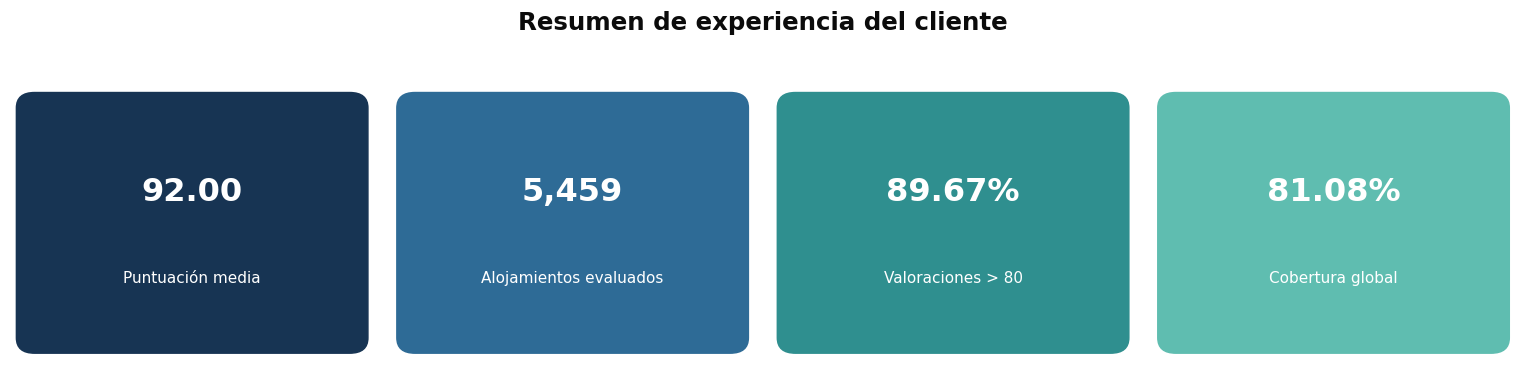

Ciudad con mayor puntuación media: sevilla


In [19]:
porcentaje_global_superior_80 = round(
    df_customer["rating_above_80"].mean()
    * 100,
    2,
)

alojamientos_evaluados = (
    df_customer["apartment_id"].nunique()
)

cobertura_global = round(
    alojamientos_evaluados
    / df["apartment_id"].nunique()
    * 100,
    2,
)

ciudad_mejor_valorada = (
    puntuacion_media_ciudad.iloc[0]["city"]
)

tarjetas = [
    (
        "Puntuación media",
        f"{indice_satisfaccion_general:.2f}",
        NAVY,
    ),
    (
        "Alojamientos evaluados",
        f"{alojamientos_evaluados:,}",
        ACERO,
    ),
    (
        "Valoraciones > 80",
        f"{porcentaje_global_superior_80:.2f}%",
        TEAL,
    ),
    (
        "Cobertura global",
        f"{cobertura_global:.2f}%",
        AQUA,
    ),
]

mostrar_tarjetas_kpi(
    tarjetas,
    "Resumen de experiencia del cliente",
)

print(
    "Ciudad con mayor puntuación media:",
    ciudad_mejor_valorada,
)


### 12.2. Puntuación media por ciudad

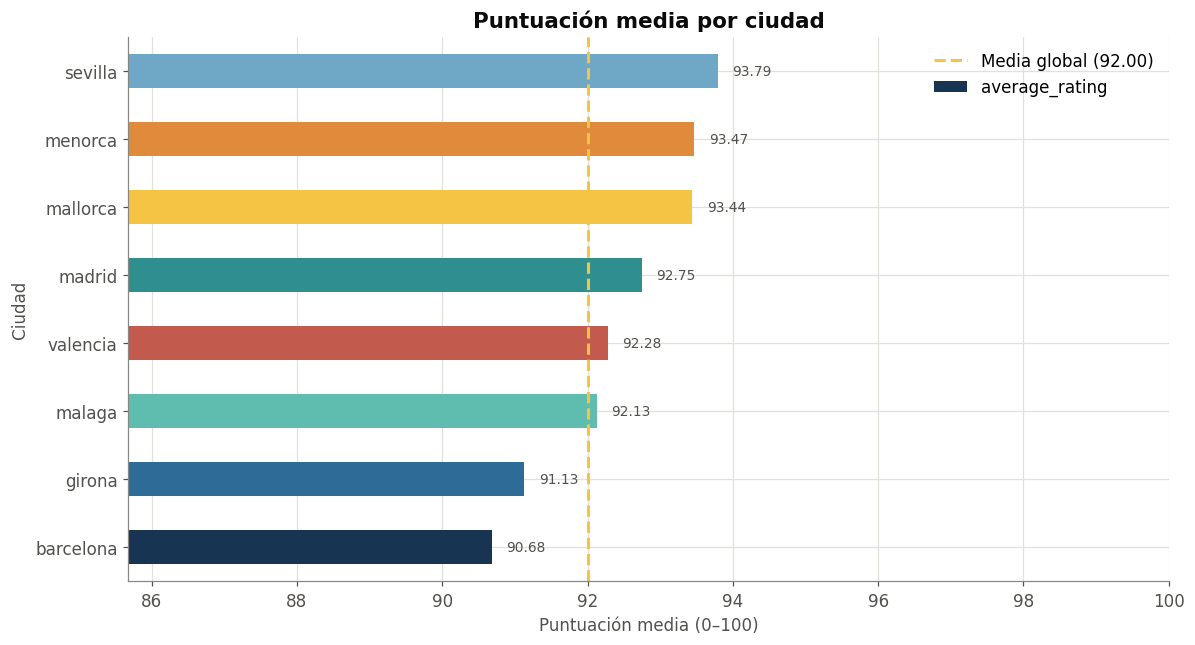

In [20]:
grafico_barras_ciudad(
    datos=puntuacion_media_ciudad,
    valor="average_rating",
    titulo="Puntuación media por ciudad",
    etiqueta_x="Puntuación media (0–100)",
    benchmark=indice_satisfaccion_general,
    etiqueta_benchmark=(
        f"Media global "
        f"({indice_satisfaccion_general:.2f})"
    ),
    limite_x=(
        max(
            0,
            puntuacion_media_ciudad[
                "average_rating"
            ].min()
            - 5,
        ),
        100,
    ),
    desplazamiento=0.2,
)


### 12.3. Porcentaje de alojamientos con puntuación superior a 80

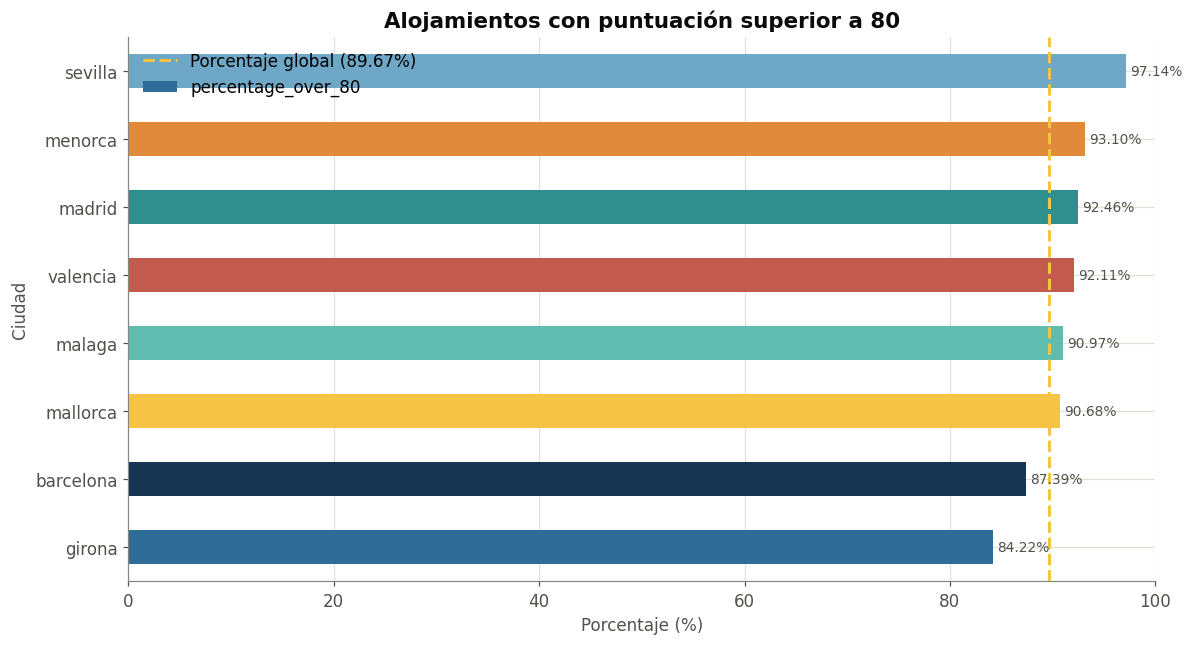

In [21]:
grafico_barras_ciudad(
    datos=porcentaje_superior_80_ciudad,
    valor="percentage_over_80",
    titulo=(
        "Alojamientos con puntuación "
        "superior a 80"
    ),
    etiqueta_x="Porcentaje (%)",
    benchmark=porcentaje_global_superior_80,
    etiqueta_benchmark=(
        f"Porcentaje global "
        f"({porcentaje_global_superior_80:.2f}%)"
    ),
    sufijo="%",
    limite_x=(0, 100),
    desplazamiento=0.4,
)


### 12.4. Puntuación media por ítem de satisfacción

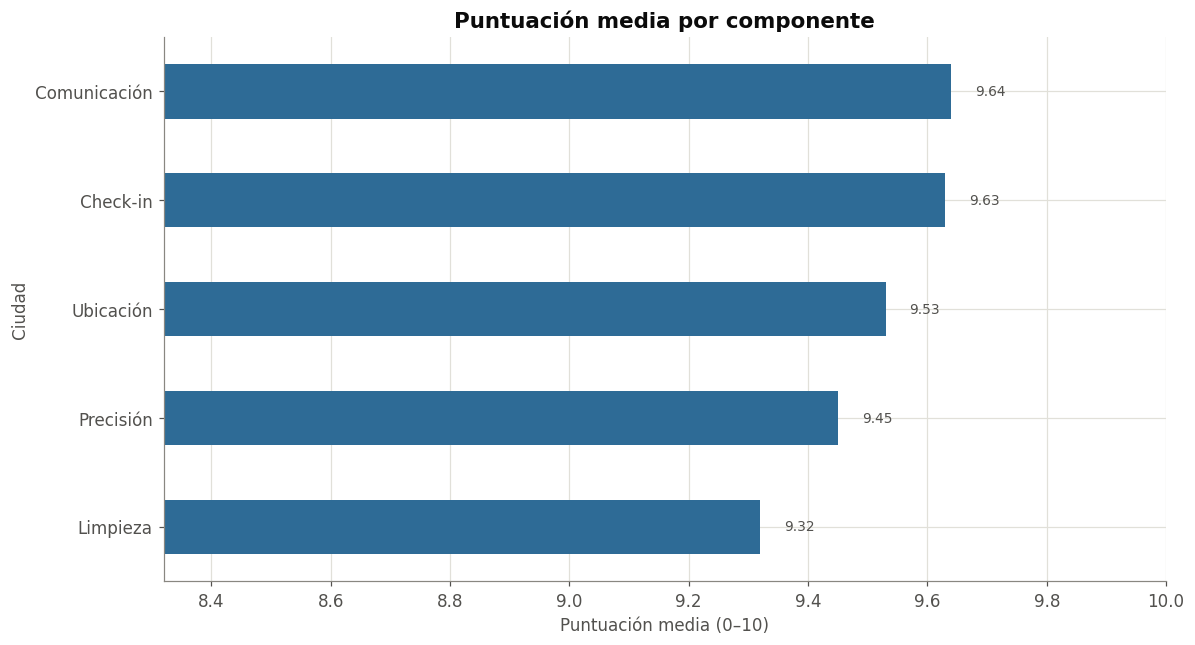

In [22]:
grafico_items = (
    resumen_items_satisfaccion
    .replace(
        {"satisfaction_item": nombres_items}
    )
    .rename(
        columns={
            "satisfaction_item": "city",
        }
    )
)

grafico_barras_ciudad(
    datos=grafico_items,
    valor="average_score",
    titulo="Puntuación media por componente",
    etiqueta_x="Puntuación media (0–10)",
    limite_x=(
        max(
            0,
            grafico_items[
                "average_score"
            ].min()
            - 1,
        ),
        10,
    ),
    desplazamiento=0.04,
)


### 12.5. Relación entre puntuación media y porcentaje superior a 80

Cada punto representa una ciudad. El tamaño del punto refleja el número de alojamientos evaluados.


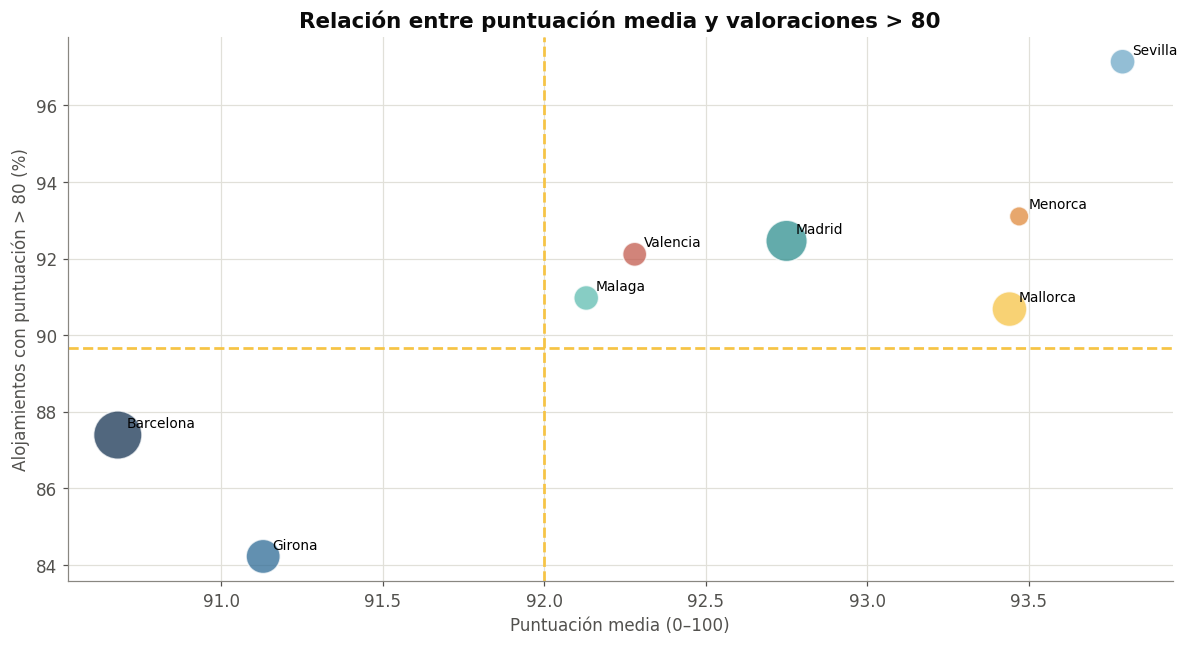

In [23]:
grafico_relacion_ciudades(
    datos=resumen_experiencia_cliente,
    x="average_rating",
    y="percentage_over_80",
    tamano="rated_accommodations",
    benchmark_x=indice_satisfaccion_general,
    benchmark_y=porcentaje_global_superior_80,
    titulo=(
        "Relación entre puntuación media "
        "y valoraciones > 80"
    ),
)


### 12.6. Cobertura de valoraciones por ciudad

Esta visualización permite interpretar la representatividad de las puntuaciones medias.


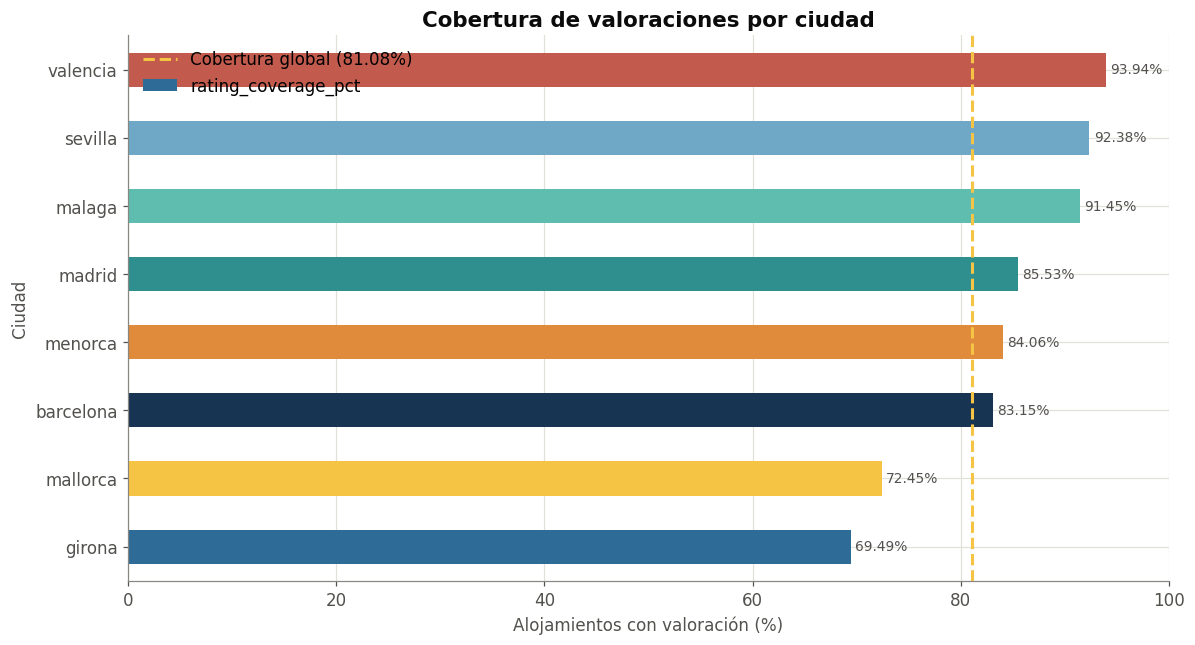

In [24]:
grafico_barras_ciudad(
    datos=cobertura_valoraciones_ciudad,
    valor="rating_coverage_pct",
    titulo="Cobertura de valoraciones por ciudad",
    etiqueta_x="Alojamientos con valoración (%)",
    benchmark=cobertura_global,
    etiqueta_benchmark=(
        f"Cobertura global "
        f"({cobertura_global:.2f}%)"
    ),
    sufijo="%",
    limite_x=(0, 100),
    desplazamiento=0.4,
)


### 12.7. Mapa de calor de satisfacción por ciudad

El mapa de calor permite comparar los distintos componentes de satisfacción entre ciudades.


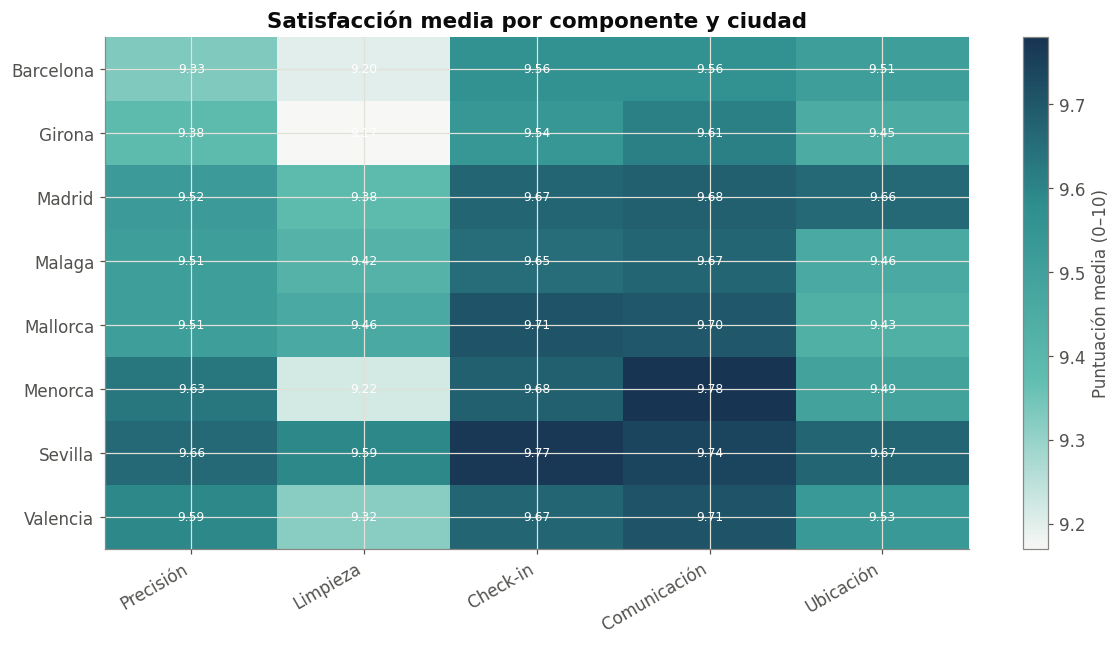

In [25]:
satisfaccion_ciudad = (
    df
    .groupby("city")[columnas_satisfaccion]
    .mean()
    .round(2)
)

etiquetas_items = [
    "Precisión",
    "Limpieza",
    "Check-in",
    "Comunicación",
    "Ubicación",
]

mapa_calor(
    satisfaccion_ciudad,
    etiquetas_items,
    (
        "Satisfacción media por "
        "componente y ciudad"
    ),
)


## 13. Resultados principales

In [26]:
ciudad_mejor_rating = puntuacion_media_ciudad.iloc[0]
ciudad_menor_rating = puntuacion_media_ciudad.iloc[-1]

ciudad_mayor_porcentaje = porcentaje_superior_80_ciudad.iloc[0]
ciudad_menor_porcentaje = porcentaje_superior_80_ciudad.iloc[-1]

ciudad_menor_cobertura = (
    cobertura_valoraciones_ciudad
    .sort_values("rating_coverage_pct")
    .iloc[0]
)

print(
    "Ciudad con mayor puntuación media:",
    ciudad_mejor_rating["city"],
    "-",
    ciudad_mejor_rating["average_rating"],
)

print(
    "Ciudad con menor puntuación media:",
    ciudad_menor_rating["city"],
    "-",
    ciudad_menor_rating["average_rating"],
)

print(
    "Mayor porcentaje superior a 80:",
    ciudad_mayor_porcentaje["city"],
    "-",
    ciudad_mayor_porcentaje["percentage_over_80"],
)

print(
    "Menor porcentaje superior a 80:",
    ciudad_menor_porcentaje["city"],
    "-",
    ciudad_menor_porcentaje["percentage_over_80"],
)

print(
    "Ciudad con menor cobertura de valoraciones:",
    ciudad_menor_cobertura["city"],
    "-",
    ciudad_menor_cobertura["rating_coverage_pct"],
)

Ciudad con mayor puntuación media: sevilla - 93.79
Ciudad con menor puntuación media: barcelona - 90.68
Mayor porcentaje superior a 80: sevilla - 97.14
Menor porcentaje superior a 80: girona - 84.22
Ciudad con menor cobertura de valoraciones: girona - 69.49


## 14. Conclusiones y recomendaciones

- El índice general de satisfacción es alto, pero las diferencias entre ciudades permiten identificar dónde priorizar acciones de mejora.
- La ciudad con menor puntuación media y menor porcentaje de alojamientos por encima de 80 requiere una revisión más detallada de la experiencia ofrecida.
- La cobertura de valoraciones debe interpretarse junto con la puntuación media. Una ciudad con pocas valoraciones puede mostrar un resultado menos representativo.
- El ítem mejor valorado indica una fortaleza del servicio.
- El ítem peor valorado señala la principal oportunidad de mejora transversal.
- Se recomienda priorizar acciones en las ciudades con menor satisfacción y revisar especialmente los aspectos relacionados con el ítem peor puntuado.


## 15. Nota sobre los resultados

No se genera un CSV departamental adicional, para mantener en la carpeta `Data` únicamente el dataset raw original y el dataset clean final acordado por el equipo. Las tablas de resultados quedan disponibles dentro de este notebook para el dashboard y la presentación.
